In [1]:
### importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Connecting to the SQL Database

In [2]:
import sqlite3

In [8]:
connection = sqlite3.connect('C:\\Users\\Admin\\Desktop\\Shift-Optimization-System\\shiftData.db')
shift_data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
shift_data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


#### Basic Data Overview

In [9]:
shift_data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [10]:
shift_data.shape

(296334, 31)

In [11]:
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [12]:
#formatting the date column into proper format from object

shift_data['date'] = pd.to_datetime(shift_data['date'])
shift_data['start_time'] = pd.to_datetime(shift_data['start_time'])
shift_data['end_time'] = pd.to_datetime(shift_data['end_time'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_23868\286065483.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shift_data['start_time'] = pd.to_datetime(shift_data['start_time'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_23868\286065483.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shift_data['end_time'] = pd.to_datetime(shift_data['end_time'])


In [17]:
shift_data['timestamp'] = pd.to_datetime(shift_data['timestamp'])

In [18]:
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [14]:
#checking for duplicates

shift_data.duplicated().sum()

np.int64(0)

In [15]:
# checking for missing values

shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [16]:
# check statistical summary of the data

shift_data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000
mean,2.048142,2026-05-20 14:23:06.478770688,2026-05-20 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118
min,1.000000,2026-05-20 06:00:00,2026-05-20 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000
25%,1.000000,2026-05-20 06:00:00,2026-05-20 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000
50%,2.000000,2026-05-20 14:00:00,2026-05-20 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000
75%,3.000000,2026-05-20 22:00:00,2026-05-20 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000
max,3.000000,2026-05-20 22:00:00,2026-05-20 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084


#### Filling the missing values

In [19]:
#sorting the dataset chronologically
shift_data = shift_data.sort_values(by='date')

#filling temperature and humidity columns
shift_data['temperature'] = shift_data['temperature'].fillna(method='ffill').fillna(shift_data['temperature'].mean())
shift_data['humidity'] = shift_data['humidity'].fillna(method='ffill').fillna(shift_data['humidity'].mean())

#fill timestamp
shift_data['timestamp'] = shift_data['timestamp'].fillna(method='ffill')


C:\Users\Admin\AppData\Local\Temp\ipykernel_23868\434580701.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data['temperature'] = shift_data['temperature'].fillna(method='ffill').fillna(shift_data['temperature'].mean())
C:\Users\Admin\AppData\Local\Temp\ipykernel_23868\434580701.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data['humidity'] = shift_data['humidity'].fillna(method='ffill').fillna(shift_data['humidity'].mean())
C:\Users\Admin\AppData\Local\Temp\ipykernel_23868\434580701.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data['timestamp'] = shift_data['timestamp'].fillna(method='ffill')


In [20]:
shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [24]:
# filling the remaining missing categorical fields

shift_data['issue_type'] = shift_data['issue_type'].fillna('No Issue')
shift_data['resolved_by'] = shift_data['resolved_by'].fillna('No Maintenance')

#filling the downtime column with 0 as it indicates no downtime when there is no issue
shift_data['maintenance_downtime'] = shift_data['maintenance_downtime'].fillna(0)

shift_data = shift_data.drop(columns=['maintenance_id'])

In [26]:
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [27]:
shift_data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

### Exploratory Data Analysis

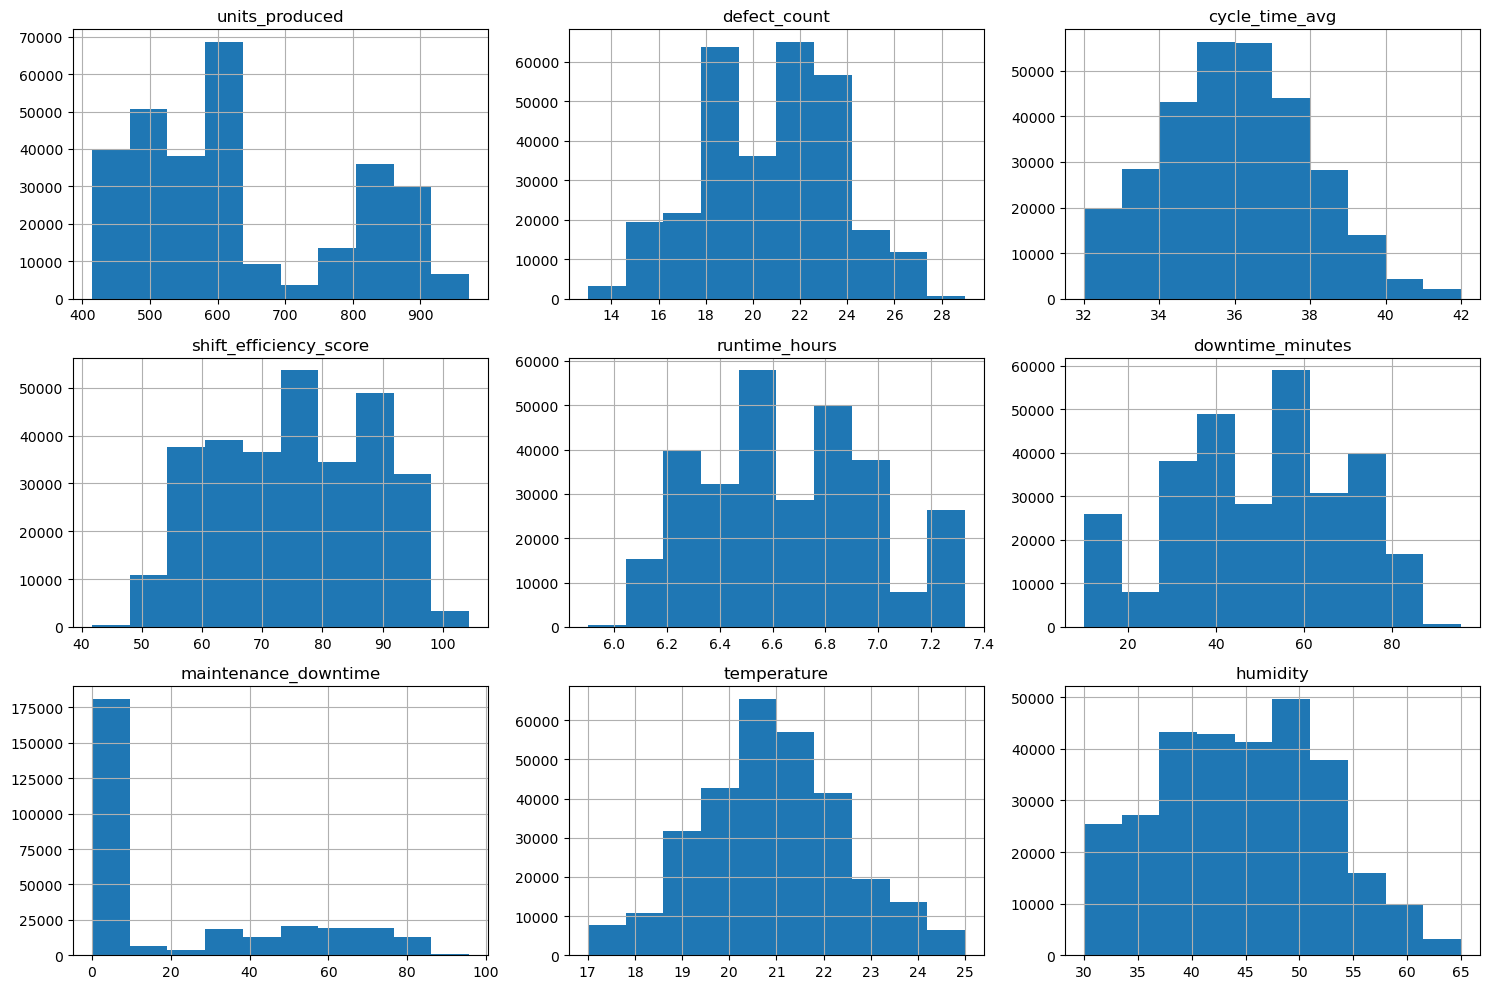

In [28]:
## Numerical data distribution
num_cols = [
    'units_produced', 'defect_count', 'cycle_time_avg', 
    'shift_efficiency_score', 'runtime_hours', 'downtime_minutes', 'maintenance_downtime',
    'temperature', 'humidity'
]

shift_data[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

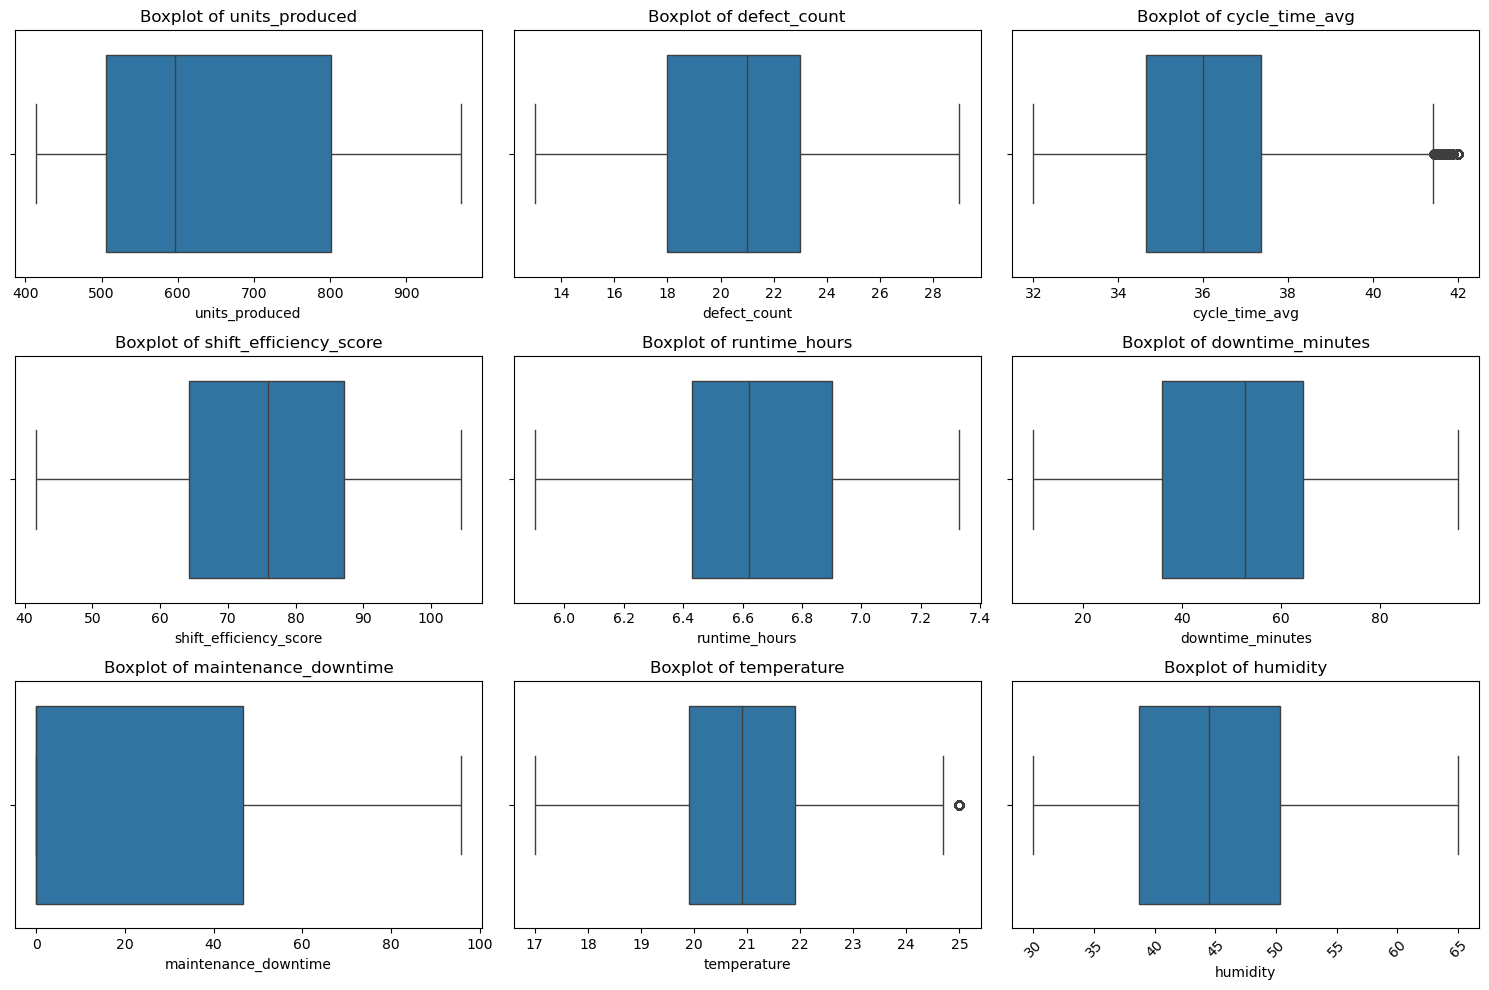

In [29]:
## Using boxplot to check if dataset has outliers

plt.figure(figsize = (15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=shift_data[col])
    plt.title(f'Boxplot of {col}')
    
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Categorical Variable Analysis

In [31]:
cat_cols = [
    'shift_name', 'issue_type', 'resolved_by',
    'machine_status', 'defect_type', 'inspection_result',
    'severity', 'experience_level'
    ]

for col in cat_cols:
    print(f'Value counts for {col}:\n{shift_data[col].value_counts()}\n')
    print(shift_data[col].value_counts())
    

Value counts for shift_name:
shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for issue_type:
issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for resolved_by:
resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07            12427
TECH_08            12290
TECH_02            12065
TECH_10            11977
TECH_05            11743
TECH_04            11275
TECH_01            10522
TECH_09            10441
TECH_06             9954
Name: count, dtype: int64

resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07       

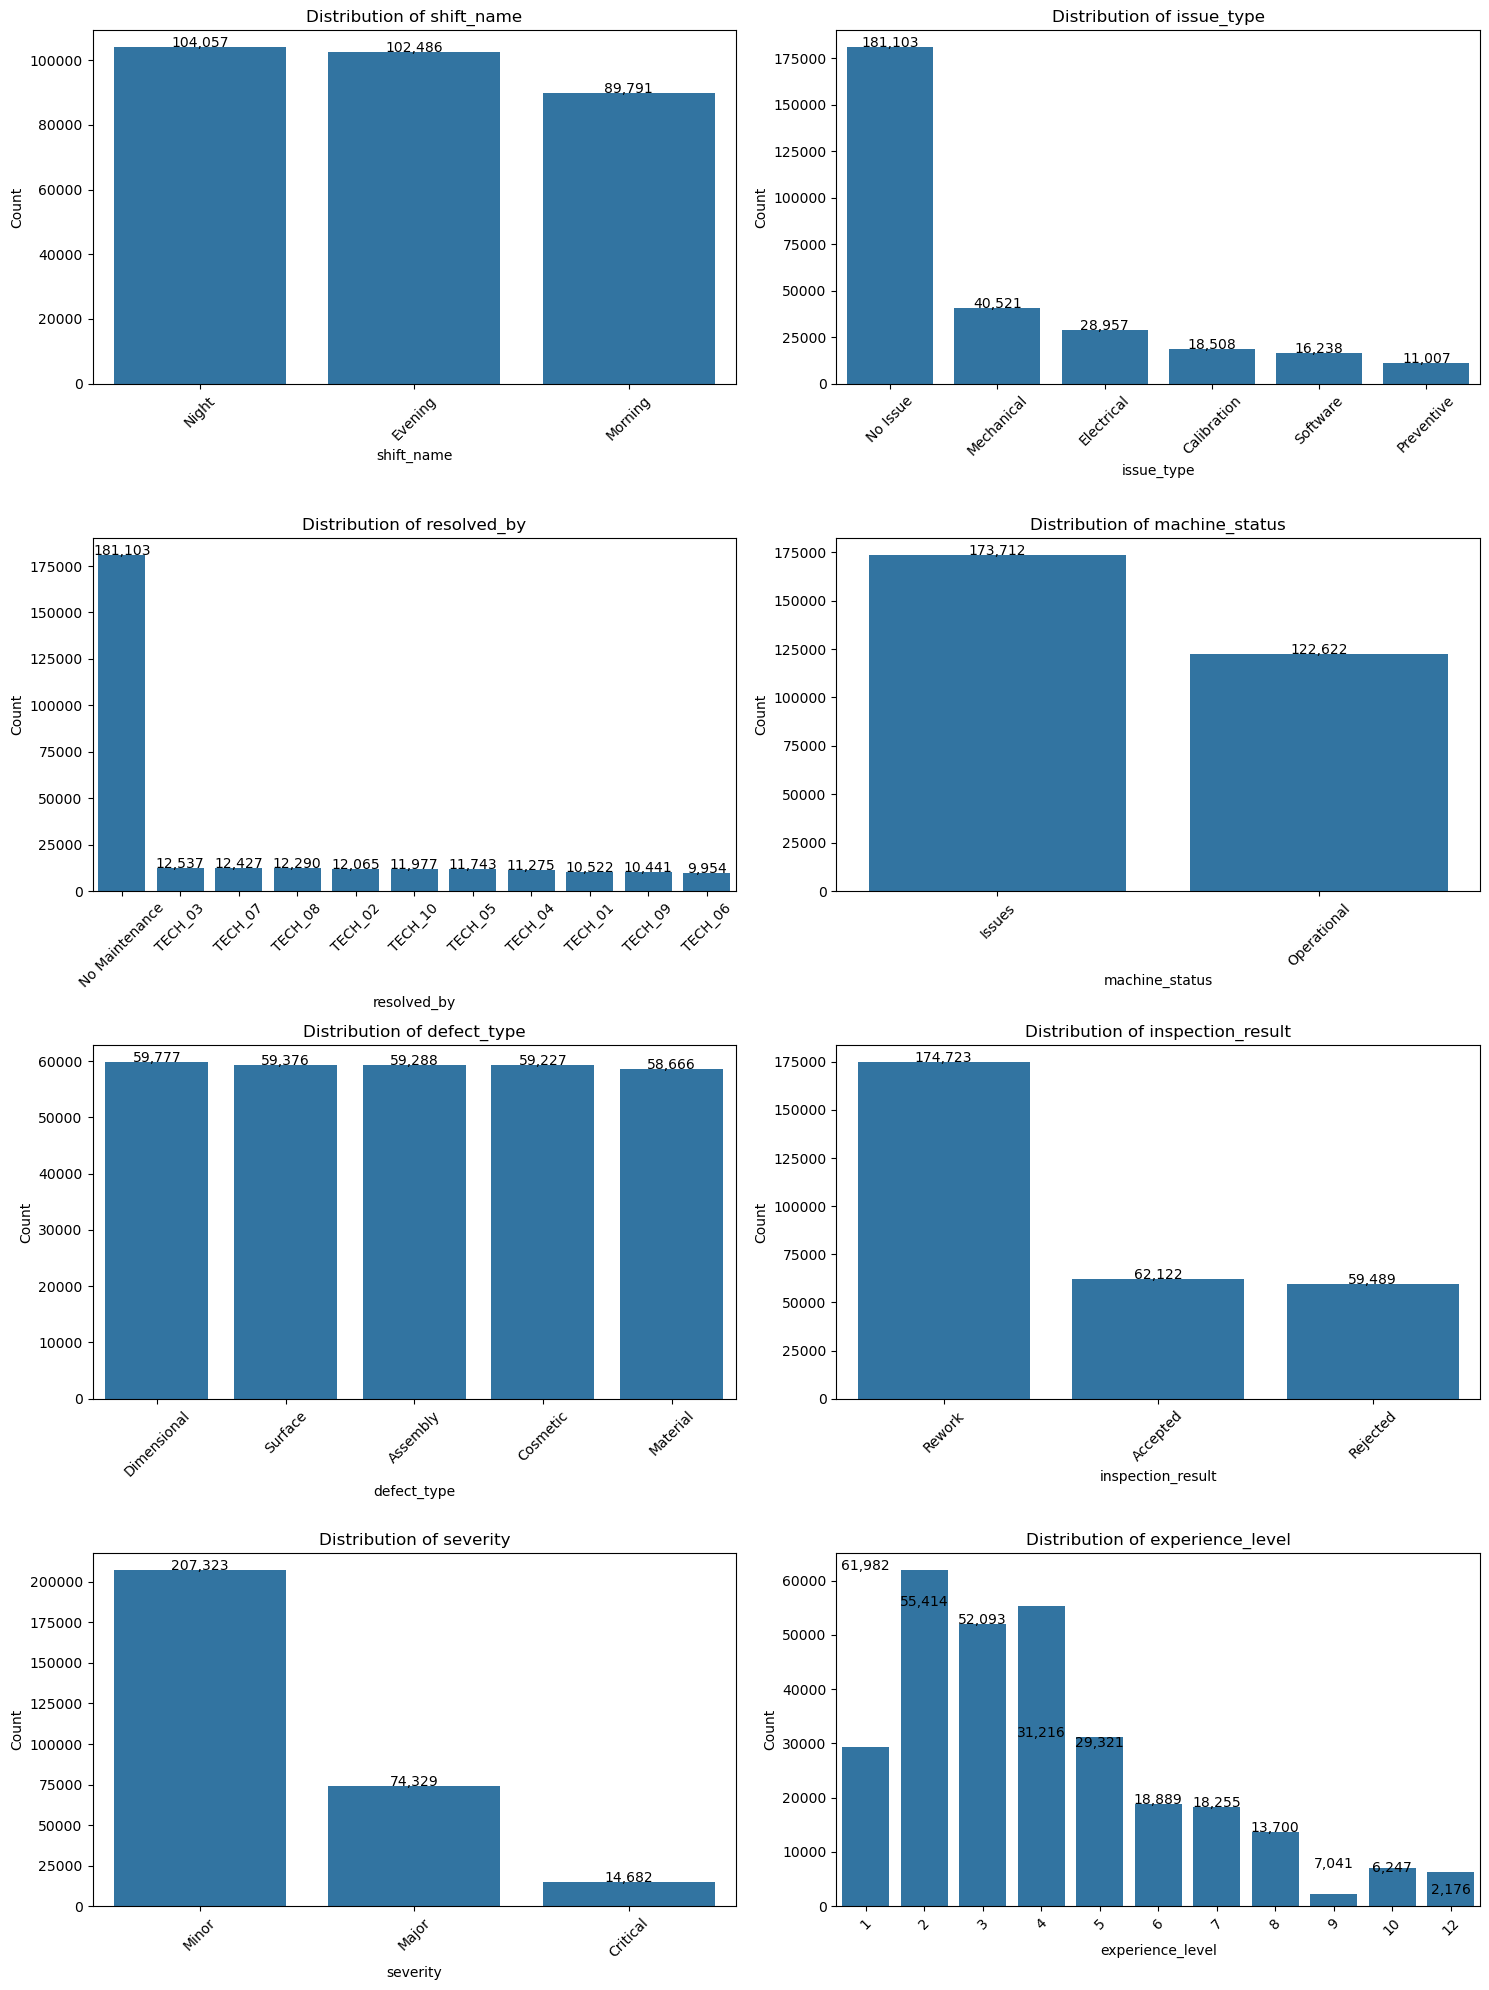

In [32]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()
for index, column in enumerate(cat_cols):
    # get the column count
    counts = shift_data[column].value_counts().reset_index()
    counts.columns = [column, 'count']

    sns.barplot(x=column, y='count', data=counts, ax=axes[index])
    
    # plot customisation
    axes[index].tick_params(axis='x', rotation=45)
    axes[index].set_title(f'Distribution of {column}')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel('Count')

    # add count labels on top of bars
    for j, v in enumerate(counts['count']):
        axes[index].text(j, v, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

#### Operational performance during maintenance and with no maintenence

In [34]:
# maintenance analysis
maintenance_data = shift_data.groupby('maintenance_flag')[num_cols].mean()

In [35]:
maintenance_data.head(5)

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,53.701075,20.860356,44.613007


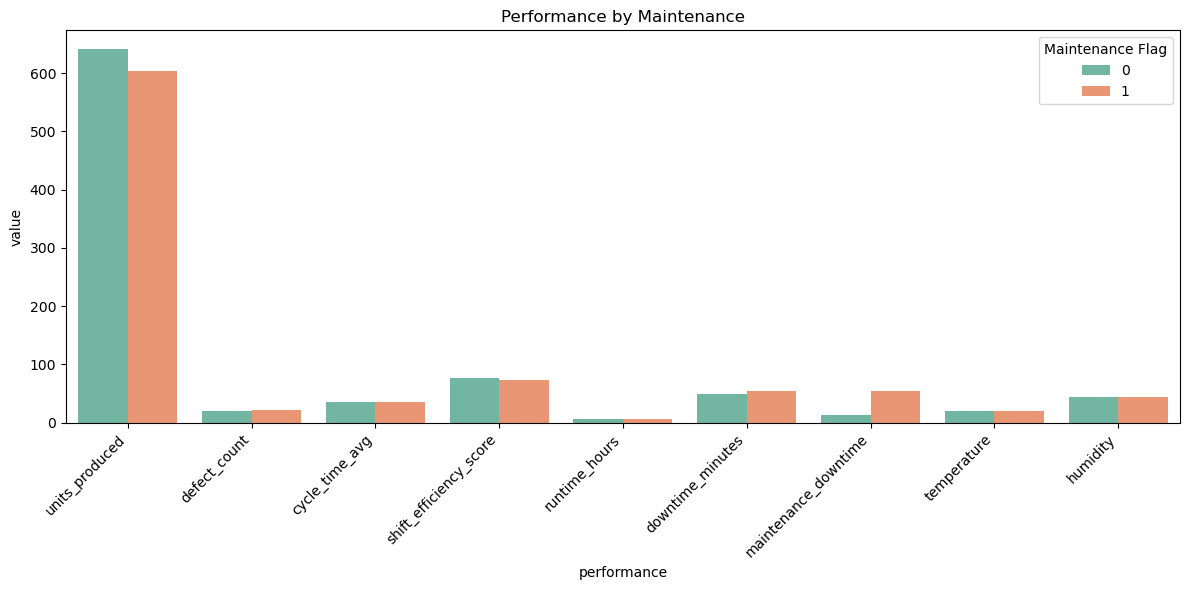

In [36]:
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars = 'maintenance_flag', 
    var_name= 'performance', 
    value_name='value')

plt.figure(figsize=(12, 6))
sns.barplot(
    x='performance', 
    y='value', 
    hue='maintenance_flag', 
    data=maintenance_plot_melt,
    palette='Set2'
)
plt.xticks(rotation=45, ha='right')
plt.title('Performance by Maintenance')
plt.legend(title='Maintenance Flag')
plt.tight_layout()
plt.show()

#### Shift Performance Analysis

In [39]:
shift_performance_data = shift_data.groupby('shift_name').agg({
    "units_produced": ["mean", "sum"],
    "cycle_time_avg": "mean",
    "defect_count": "mean",
    "downtime_minutes": ["mean", "sum"],
    "shift_efficiency_score": "mean"
}).reset_index()

shift_performance_data.columns = ['shift_name', 
                                  'average_units_produced', 
                                  'total_units_produced', 
                                  'average_cycle_time', 
                                  'average_defect_count', 
                                  'average_downtime', 
                                  'total_downtime', 
                                  'average_efficiency']

# calculate defect rate
defect_sum = shift_data.groupby('shift_name')['defect_count'].sum().values
units_sum = shift_data.groupby('shift_name')['units_produced'].sum().values

shift_performance_data['defect_rate'] = (defect_sum / units_sum) * 100

shift_performance_data.sort_values(by='average_units_produced', ascending=False)


,shift_name,average_units_produced,total_units_produced,average_cycle_time,average_defect_count,average_downtime,total_downtime,average_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


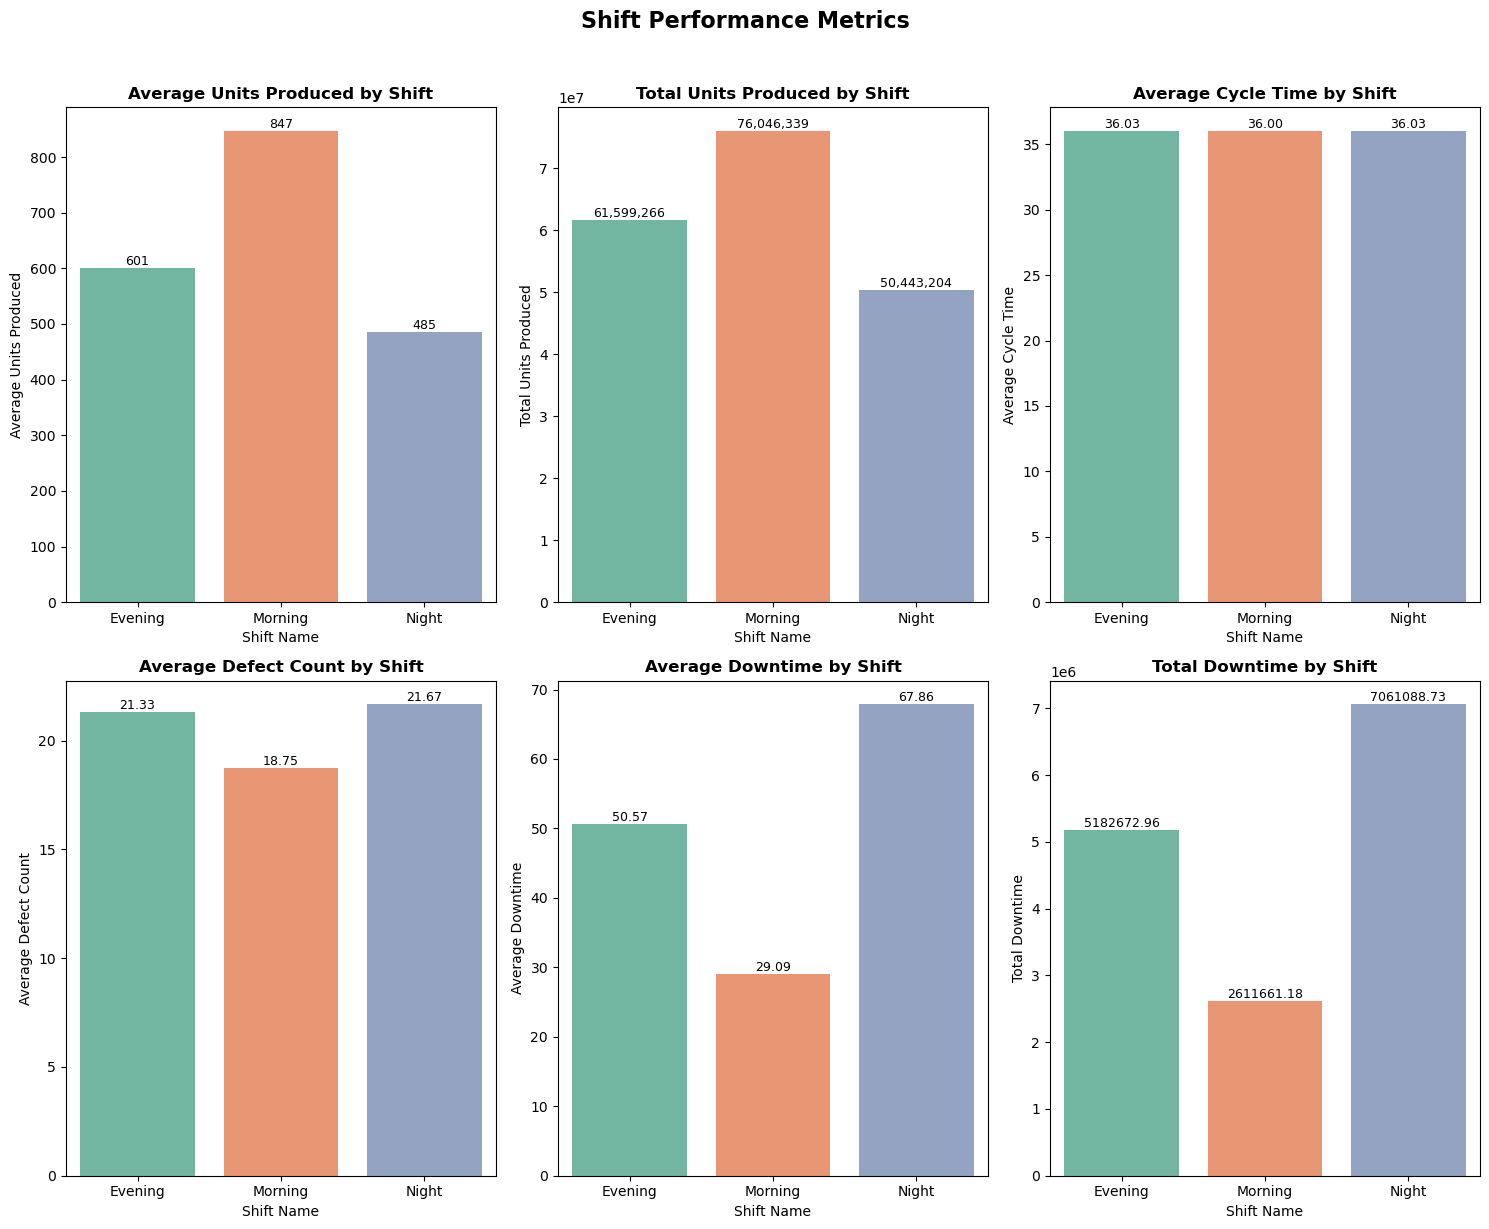

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()
matrics = ["average_units_produced", "total_units_produced", "average_cycle_time", "average_defect_count", "average_downtime", "total_downtime"]
for i, metric in enumerate(matrics):
    sns.barplot(data = shift_performance_data,
                    x = 'shift_name',
                    y = metric,
                    hue = 'shift_name',
                    palette = 'Set2',
                    legend = False,
                    ax = axes[i])
    axes[i].set_title(f'{metric.replace("_", " ").title()} by Shift', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Shift Name')
    axes[i].set_ylabel(metric.replace("_", " ").title())

    for j, v in enumerate(shift_performance_data[metric]):
        if 'units' in metric:
            axes[i].text(j, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
        else:
            axes[i].text(j, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)  

plt.suptitle('Shift Performance Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Shift Performance based on production output per hour

In [49]:
shift_data['total_operation_hours'] = shift_data['runtime_hours'] + (shift_data['downtime_minutes'] / 60)

output_per_hour = shift_data.groupby('shift_name').apply(lambda x: x['units_produced'].sum() / x['total_operation_hours'].sum())

output_per_hour

C:\Users\Admin\AppData\Local\Temp\ipykernel_23868\2852359934.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  output_per_hour = shift_data.groupby('shift_name').apply(lambda x: x['units_produced'].sum() / x['total_operation_hours'].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
dtype: float64

In [51]:
output_per_hour_data = output_per_hour.reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x='shift_name', 
    y=output_per_hour,
    data=output_per_hour_data, 
    palette='Set2',
    fontsize=12,
    fontweight=9,
    hue='shift_name',
    legend=False
)

ax[0].set_title('Output per Hour by Shift', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Shift Name')
ax[0].set_ylabel('Output per Hour')

for i, v in enumerate(output_per_hour_data):
    ax[0].text(i, v, f'{v}', ha='center', va='bottom')


merged_data = shift_performance_data.merge(output_per_hour_data, on='shift_name')
# Plot2, Plotting the shift efficiency score

sns.barplot(
    x='shift_name', 
    y='average_efficiency',
    data=merged_data, 
    palette='Set2',
    hue='shift_name',
    ax=ax[1],
    legend=False
)

ax[1].set_title('Shift Efficiency by Shift', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Shift Name')
ax[1].set_ylabel('Shift Efficiency')

for i, v in enumerate(merged_data):
    ax[1].text(i, v, f'{v}', ha='center', va='bottom')

Error in callback <function _draw_all_if_interactive at 0x0000024E1379E0C0> (for post_execute), with arguments args (),kwargs {}:


ConversionError: Failed to convert value(s) to axis units: 'shift_name'

ConversionError: Failed to convert value(s) to axis units: 'shift_name'

<Figure size 1400x600 with 2 Axes>